In battery engineering, controlling how metal grows at the microscopic level is a critical safety requirement. If electrodeposition is uneven, it can form sharp, needle-like dendrites that grow across the electrolyte and cause massive internal short circuits. Therefore, understanding and suppressing this dendrite formation is essential to preventing catastrophic battery failure.

In this tutorial, we will build a minimal kinetic Monte Carlo (KMC) model for metal electrodeposition using pyZacros. By explicitly simulating individual atomic events (such as ion diffusion in the electrolyte, electrochemical reduction at the interface, and surface self-diffusion on the electrode), we can visualize how macroscopic morphologies develop from the electrode.

Inspired by the work of Vishnugopi et al. **Surface diffusion manifestation in electrodeposition of metal anodes** [Phys. Chem. Chem. Phys., 2020,22, 11286-11295](https://pubs.rsc.org/en/content/articlelanding/2020/cp/d0cp01352h), the core goal of this tutorial is to show how the competition between different surface diffusion pathways dictates whether a deposited film grows smooth and flat, or rough and fractal. Here we describe a simplified model. For surface diffusion, we will specifically include terrace diffusion and step-detachment (diffusion away from a step edge). By the end, you will have run a short simulation and visualized the direct link between atomic-scale kinetics and the resulting electrodeposition morphology.

OK, let's start!

First, we import the main packages we need:

In [1]:
import scm.pyzacros as pz
import math

Next, we configure our environment for reproducibility and visualization. We set a deterministic random seed and import the `matplotlib` tools needed to visualize the simulation results.

In [2]:
import random

random_seed = 100
random.seed(random_seed)

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.animation as animation

plt.rcParams["figure.figsize"] = [7, 7]

from IPython.display import HTML

Now, define a convenient set of physical constants:

In [3]:
kB = 8.6173e-05  # Boltzmann constant in eV/K
F = 96487.0  # Faraday constant in C/mol
R = 8.314  # Gas constant in J/mol/K
N_a = 6.022e23  # Avogadro constant in 1/mol

To reproduce these morphological changes, this tutorial will guide you through the complete setup of the pyZacros simulation. We will start from the ground up by defining the species and their energetic cluster expansions. With the physical entities established, we will build a 2D lattice and populate it with our initial electrode surface and electrolyte ions. From there, we will encode the actual physics (ion transport, reduction, and surface diffusion) into a network of elemental reactions. Finally, we will wrap these components into a ZacrosJob calculation, execute the KMC simulation, and animate the results to watch our metal deposit grow dynamically over time.

Species and Energetics (Clusters)
---------------------------------

We first need to define the fundamental building blocks of our system. As shown in the diagram below, we allow each lattice site to take on one of three states: an empty site `*` (representing the background solvent), a solid deposited metal atom `M`, or a solvated metal cation `M+`.

<img original-file="Electrodeposition_images/Species.png" src="data:image/png;base64,
iVBORw0KGgoAAAANSUhEUgAAALQAAAAeCAYAAACFSjS6AAAACXBIWXMAAA7DAAAOwwHHb6hkAAAA
GXRFWHRTb2Z0d2FyZQB3d3cuaW5rc2NhcGUub3Jnm+48GgAADVlJREFUeJzlnHl8VUWWx791k8cL
mySBEMhCBwg7zhATpdUQbRAcAYk0DGpryzoqpGG0pW0l4NjIoAygfkZUUJuwNIpoA4GANGCzdbdM
FtAA0nTEQCAvZmUR8hKSvDN/3HtfEsjyXnjZ6N/ncz+vqm7VOfXqntpOnTpKRKgPSikFRALjgHuA
7sbTFsgBbMApYBuwR0SK6yV6i0Ip5Q3EoLdVBBAIhBivzwO5wBFgO3BQRMqbo54tAUqpdsAo4GGg
HxCELld2dLnKAf6KLldHxBVhFZFaH8ACzAKyAHHxKQY+AILron2rPcBtwEKgyI22KgJ+B3Rs7vo3
cVuFGDJS7EZbnQVmApa6aCuDQU295yHgf4FwMy0sLIyYmBhCQkIICAjAarVSUFBAbm4uqamppKam
UlFRYWYvBt4CXpVbfBRSSj0DLAK6GCngF44KjIC2XfQHwF4A9gIk9yhc+A79OwGQD8SLyIdNXfem
hFLKArwKPI8+u6N5edN36H2ERw3DNzCYTgHduFZi51J+DoXnMjm2fwd5ZzKqkskA5ojIrhp5XC/Q
xvLit8B/A5qmacTGxjJ9+nR69epVZ4UvX77Mtm3bWLlyJUVFRWbyPmCSiBS4+f9bPJRSVuB9YCoA
3j6o8FhU77HQtnPdhe0FyOkdSMZWqCg1U1cDs0SktI6SrRJKqS7AZ8D9AB07d2X0rPkMjX2Sdp38
6iyb89237PloGYe3rsOhD5gOIB5YItcJcDWBNoT5I2AawODBg3n99dfp3bu3W5UvLi5mxYoVrF27
1pxiMoFhIpLtFqEWDKVUW2A3EA2ggu9FRcwEH3/3CJUUIUffR7L/aqYcAh4UEbsHq9usUEqFAAeB
nkopHpj2a8bOeRVruw5u0bFlnGDdS1M5k55iJq0GZlQV6usFej7wGsDo0aNZtGgRPj4+Df4jX3zx
BfHx8ZSUlAAcRRfqqw0m2EJgdPwNwOOgUP0mogZPAaUaSFGQU58jx9eA/j0+R5/V6t8EtXAYHf8A
cKfF6sMTr63ip+OfajC98mulbFjwLF9tXmMmxYvIYic/s82UUg8DiYAaO3YsS5YsQTX4A1XiwIED
xMXF4XA4AD4RkV/cNNFmhlIqHn3NjLp9GqrfRI/QlVOfIccSzOjLIvKGRwg3I5RSnwKTNC8vZq5M
5Pb7x9w0TREhYe4vSd62AfTlR6yIJIEh0MZa8CTQc8iQISQkJGC1Wm+asYmEhASWLl1qRoeLyD6P
EW9iKKV6oKsofVTYSFTU8x6lLylvImf3gq666isi5z3KoAmhlBoB7AWY+PJyHpj2a4/RList4c0n
f0bm14cBvgcGiMg1zXg/G+ipaRoLFy70qDADTJkyhYiICDP6plJKqyt/C8ciwAdrJ9S/PuNx4vo6
3Bd0LcBrHmfQRDC+8RKAsH+5ixFTb77jJ74Zz65V+qRlsfoweUkCmpc3QC8gDkAzGL8AMGHCBMLD
w2sh13AopXj+eecfGgKM8DiTJoBSKhh4AkANfAIs7TzPxLstaoBzVfaUUqq755k0CUaiH8Yx8eVl
Hlm+lhZfpcxeeWbXrVd/7pk41YzOVUpp3sDdQDeAp55q+GK9PkRFRTFo0CBOnDgBMB7Y02jMGg+x
gIZ3W1TYqBozRPbqhG8HbwBOnruC7UJ1DVx0fz+sbfQJKu30ZS5eLbuBhgobpa+ly+2awXOl5/5C
k2E8QI/BkYRHDav2IjfzH5Re/RGAzqE9ad+pumbIlnGC8tISAPyDe5Ca9CkA5//+DRarD/vXrwAg
5hczGTHlOf7y6YegnzIO1UzGYWFhbqvn3MXw4cPNYKzyRJdteowHUN3vBK82NWY4X1jCK//eh90L
7mLZ5AHV3g0I7kDSvCh2L7iLrrdZ+dFey3mTVxtUtygz9oinKt9UMGb9cQARo35+w3txVLB+3gwW
j4/ij2/8ptq7ouyzvDHhLhaPjyIj9RAIZKYnk5mezOWCXC7m2ZxxEQfdwwcS2LOfWfwRDWNaiI6O
drnC6enpxMfHs3HjRp5++mmXy1XhEWQ8rQ2RAATeUWuG3Eul7D9eyDdnfuTnP+1GsH+l2nN0ZACH
/3ERgPSzl6lw1KGVq+QRVXumFgvTJoOB0TfOZN16D2Dwz8YQ2LMvKUmfcOVC5Znb0T1b6B1xDwAD
7h1JB/8Api5dx9Sl6xgYPYohI2KdcS9vCwADhzl5RGkGc4KDg12u7bJly7BYLDz66KPExMS4XO46
Hq1KoA19qn6k1S6wzrwCrPjiDBYvxTOjQgHwbW/hSklF3UJcFe27miF/pVTDDwOaB84P3TkkrMYM
mtK478k4ykrs5pKBshI7muaFV5uaZ7/a4B/0Eydfp0AHBAS4TCA0NJRNmzYxadIk+vfv73I5Pz8/
LBaLk7nLBVsGnB1QuXAauOGQjbxL13h6ZA98LBqP3dudz7/KcZmZ8nEenStaWefHqK+3pQ3tfWs3
AbhnwlTaduzE/j+8S0V5GSk7NhLx4I1LFBNjfrWgRm2Jb6CzeYI1DAsZdw6l5s2bx+zZszl79iwz
ZsygoMA1M40q1lagK8RbE6TGYC0oLXOw+s/nCLitDY9FB+HfwULhjzduAF1i10rbSkTMk88a4dO+
I3ePn8zF3Gy+3rOVi7nZ+AbWPs619+1co91HVZnS0G2Zyc/Pd7m2b7/9NjNnzmTz5s2Ul5djt7tm
dlBUVER5uXMjZHOZYcuADfNDlRTVk1XHyj9lUV4hLJ/cn93fuGebJfZCZxD4wa3CzQ8bQEV5GVcu
FtaZ8b4n41CaxqZFzxEe6fo+riou5jpNhLK90Y2o+9lsrstXUVERH3/8MYWFhcTFxREaGupSuZyc
alOu6/NvC4CIlCilLgD+FOfVmbdtGy8AzhWWsDU5l9AuPqSevgSAl6aq/daKYucAUyQiJTdR9eaA
U5iKss/S0f/G5Wx52TUAAnv2ZdCwBymyZdF36P36S2PEFYdrE1ORLcsM5ngDKcD9hw4dcrm2y5cv
dzlvVRw8eNAMZtP6RmiAVGAUP6RBLXroh+4I4I6et/EfD4SyZt953k7KJMjQdIyJ7IrFWyPt+0s8
Fh3EuYLvuVCDHhqAH1LNULLH/0XjIxv9dk7IiUO7+Mnt1RU13+xN5Ni+JDoFBhHz+LMMn/yfTqH8
evcWcs9k0K6TH4c2rmLsnFfp4NelTmYn/7LbDCYr9IOVvwFs3769UXXREydO5NtvvwV4T0TiGo1R
I0Ep9SzwPt5t0R7+pFZd9E2j4hqO7Y9DuR3gWRFZ1TiMGg9KqfeAmT0GRzJvS2q9+RsKW8YJFo4e
bEbv1oD/wxgt165d22iMU1JSTGEG2NJojBoXiUAF5XYk80+NxkQyd5nCXIF+n641YgtA1vE0MlIO
1pe3wfgy4S0zmA0kayLiAJYCbN68mYyMjNrKNhgiUtXaLhn40uNMmgAikgOsA5CTG6CsEUy7y+3I
yY1mbI3BszViL/oSjT++MdctLZqr+OH0Sb7a7ByE/0dEHKbV23vA9w6HgwULFlBa6tkbQKtXr+b4
8eNm9MVWbrj+CmCn9DLytedNLOTIu1B6EfQ7mf/lcQZNBOMb/wbgTHoKe3/fsH1XbSgrsbPmxSk4
KsoBTmPYu2gG82vAHMCRnp7O/PnzPdaj9u3bx1tvOaeFP4jIAY8QbiYY9skLAeTsl8ipzzxH+++b
kKw/m9HftfYrayKyH/gYYMvSlzi2L8lTdFn38nTOpCeDrqOfY8gwWpVMO4D5ADt27GDu3Lnm1akG
Y+fOnbzwwgvmbZUjgOcNiJsHSzA+lBxbo1vG3dQAIPptlRPO6fMzjGXgLYAZQLLDUcGqX02sukRo
EMpKS1j72ymkJH1iJs0TkZ1mpKZb3x8alWDQoEEsXryYPn36uMX0ypUrvPPOO6xfv95MOg3EiEhr
VNXVCMO2Yxe6UxlU0N2oiFn13/a+HvZC5Oi7iO2wmXIA+LdWqHuuFYYd+UF0Q3xGTHmOh59biE/7
jm7RyT51jLUvTSXreJqZ9KGIVLOOq9Evh1LqRWAx4KVpGuPGjWPatGn1Gv9funSJxMREPvjgg6pu
DL4EHhWRuo+MWiGUUm3Q9x/TAfCyovrEonqNgXb12MYU5yOnk5DvEqHimpn6ERBnTp+3EpRSnYFN
wHCAjv4BPDQrnqGP/PIGe+jrYcs4wZ6PlnJ463rzsKUC/c7lDbNYXY5mRgHvAH3NtB49ehATE0No
aChdu3bFarWSl5dHXl4eqamppKWlVXU0cxVYDrz2T+BoZga6HxPDRE6Bb+9KRzOmcBfnVzqaufhd
VRJ56FPn75u04k0Mw03aK+g3pNqB7mimz53DCI8ahl+3EDp17a47msmzkZ91muP7d5KfdboqmVPA
bBGp+YJIPS6bvNHXvWdw3WXTVfQdZ/fmdjnVlA/QEd0rUKEbbVWIrsno0Nz1b+K2CjJk5KobbZVp
yKJ3XbRrHaFr6F13UOms0TTgbod+KGNDvzWehO6s8ZZxkuIujFEoGt0BYSS6s0bT2OUcurPGNHRn
jYdEpKImOv8MMPYhI9Hbqj+VFz+KqXQC+jdgm4gccYXm/wO4tTlZihSjWAAAAABJRU5ErkJggg==
" />

In [4]:
s = pz.Species("*", denticity=1, kind=pz.Species.SURFACE)
M = pz.Species("M", denticity=1, kind=pz.Species.SURFACE, mass=1.0)
Mp = pz.Species("M+", denticity=1, kind=pz.Species.SURFACE, mass=1.0)

Next, we use Clusters to define the energetics of these species. To keep this model minimal, we will stick to one-site energetic terms for `M` and `M+` and assign them a baseline energy of zero. We also intentionally omit lateral interactions. In pyZacros, this means our cluster expansion is simply a single site (`s`) occupied by either an `M` or `M+` species.

In [5]:
M_cluster = pz.Cluster(label="M", site_types=["s"], species=[M])
Mp_cluster = pz.Cluster(label="Mp", site_types=["s"], species=[Mp])

The Lattice
-----------

Our first step is to construct a 2D square lattice with nearest-neighbor connectivity. We set the distance between adjacent sites to 3.5 Å ($a = 3.5$), which corresponds to the atomic spacing of our metal electrode. The lattice has periodic boundary conditions along both axes. Following the reference paper, we map the liquid electrolyte onto this same crystalline structure. We capture the physical difference between the liquid and solid phases indirectly by assigning different kinetic rates to their respective diffusion mechanisms. For the simulation size, we intentionally chose a 100 x 100 grid. This specific scale strikes the perfect balance: it lets us track individual atomic hops while providing a large enough canvas to clearly see macroscopic features like nucleation density, growth front roughness, and island coalescence.

The code below creates this lattice and plots it so we can verify the setup is correct before moving on.

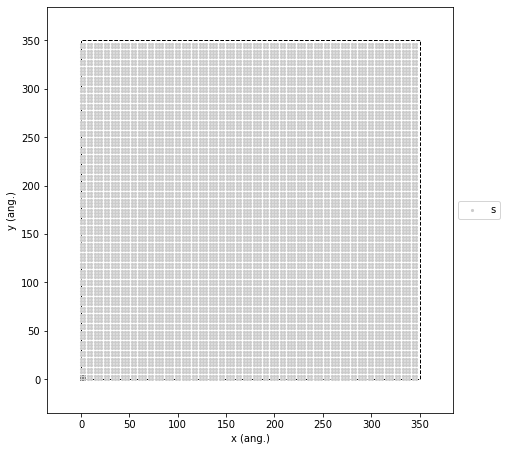

<AxesSubplot: xlabel='x (ang.)', ylabel='y (ang.)'>

In [6]:
a = 3.5  # Lattice constant in ang

lattice = pz.Lattice(
    cell_vectors=[[a, 0.0], [0.0, a]],
    repeat_cell=[100, 100],
    site_types=["s"],
    site_coordinates=[[0.000000, 0.000000]],
    neighboring_structure=[[(0, 0), pz.Lattice.EAST], [(0, 0), pz.Lattice.NORTH]],
)

lattice.plot(marker_size=1, markers=["o"], colors=["0.8"])

The Initial State
-----------------
Once the lattice is built, we need to set up our initial "experimental" conditions. First, we create a Growth Front. We seed a horizontal line of `M` atoms along the bottom and top edges of the lattice. This acts as our initial conductive electrode surface where deposition will begin. Next, we add the electrolyte by randomly filling 20% of the remaining lattice sites with `M+` ions. This specific 20% concentration provides a sufficient ionic flux to trigger visible competition between the two key processes, the rate at which ions reduce onto the surface, and the rate at which they diffuse along it.

In [7]:
initial_state = pz.LatticeState(lattice, [M, Mp, s], initial=True)

for sid in range(0, 100 * 100, 100):
    initial_state.fill_site(sid, M)
    initial_state.fill_site(sid - 1, M)

initial_state.fill_sites_random("s", Mp, 0.2)

0.2

To verify that our initial state is configured correctly, we can visualize it using the following code:

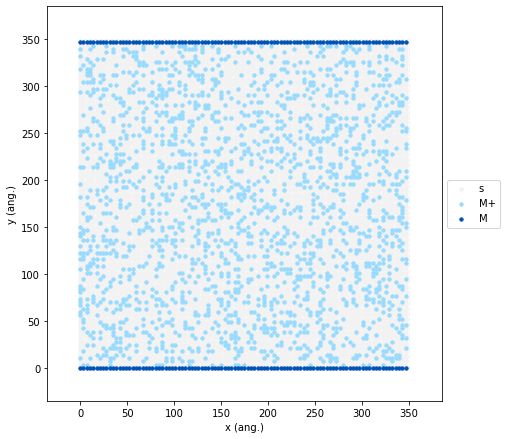

<AxesSubplot: xlabel='x (ang.)', ylabel='y (ang.)'>

In [8]:
initial_state.plot(marker_size=2.5, markers=["o", "o"], colors=["#98dbff", "#0053b6"], lattice_color="0.95")

Elemental Reactions & Bulk Diffusion
------------------------------------

The core of any KMC simulation is its reaction network. In our model, the electrodeposition dynamics are driven by four different elementary events:

1. **Bulk Diffusion**: `M+` ions swap places with neighboring empty sites (`*`) to simulate random walk transport through the liquid electrolyte.
2. **Electrochemical Reduction**: An `M+` ion adjacent to a solid `M` atom receives an electron and is reduced into a newly deposited `M` atom.
3. **Surface Diffusion**: Deposited `M` atoms hop across the surface. We explicitly track two pathways: terrace diffusion (moving along a flat plane) and step-detachment (moving away from a step edge).
4. **Ion Replenishment**: A background source term acts as an infinite reservoir, continuously introducing new `M+` ions to maintain a steady concentration.

Now, let's translate each of these physical steps into pyZacros elementary reactions.

**Electrolyte Diffusion**

First, let's model how ions move through the liquid. We define ionic electrolyte diffusion as a reversible two-site hop where an solvated `M+` ion swaps places with an adjacent empty site (`*`). On the left side of the image below, there is a representation of this process using graphs, as needed for pyZacros, which in this specific case consists of only two nodes. On the right side is the enumeration of the graph's nodes. This graph is trivial, but it will be very useful later for more complex reactions.

<img original-file="Electrodeposition_images/IonDiffusion.png" src="data:image/png;base64,
iVBORw0KGgoAAAANSUhEUgAAAagAAAAzCAYAAADCZJz0AAAACXBIWXMAAA7DAAAOwwHHb6hkAAAA
GXRFWHRTb2Z0d2FyZQB3d3cuaW5rc2NhcGUub3Jnm+48GgAAHd5JREFUeJztnXl8TWf6wL/vJRFJ
kAhCIrZqihpUbbXU1pQWSQy1jGX4tSW1dHQMMrVVUY2qlmIwZrRVpWptkA6CSkozNZYWLUVUBFlI
IkQSkvf3xznn9iaynJt7bxJ6vp/P/XzuOfe82z3nvMvzPO/zCCklBgYGBuUFIUQ1IFU9XCmlfK0s
62NQdpjKugIGBgYGBgYFYQxQBgYGBgblEmOAMjAwMDAolxgDlIGBgYFBuaRiWVfAwMDAIB93gBfV
75fLsiIGZYswrPgMDAwMDMojxgrKwMCgXCGEEEB19TBTSnmnLOtjUHYYOigDA4PyRlUgWf0sKuO6
GJQhxgBlYGBgYFAusUrEJ4T4A9AZqA34Ai5AInAFOAdESinv2ruSjkII0RDoAdRFaZMHkABcAy4A
e6WUaWVXQ4OCEEK4AM8AfoAPyn1LBq4DsUCMlPJ+2dXQOoQQjwP9gIYobaqF4kkhAeXdOgh88zC1
yUAfQogKwBMo/WkdwA24itKvnpVS3izD6lmF2pZnUJ7lpih9qg9wm9+e5W+BHVLKeF2ZSimL/KgF
LATOA7KYz21gC9CruHzL6gNUA2YAJ3W0Jwv4DzAUMJV13X/PH5TV/kDgSyC9mPt2A/i0nD+HlYEp
wGkdz6HWpn8Djcu67qXw31SzaPc/yro+DmifAPoA/0IZiAq75/eBQ8BkoE5Z17uI9ngA76iDkJ5n
ORf4DuhbXN6FWvEJIaoC04BJgKt23t2zBjXrN6ZqDW8qubqTmhBPWuI1En/9BZmba5lFJDBNSvm/
AgsoZYQQzsB4YDrgpZ2vUqUK9erVo2bNmri7u3Pz5k0SExO5dOkS9+/nmbAeR2nP3tKtuYEQ4nng
XeApy/MeHh7UqFEDDw8PUlJSSExMJD09PX/yb4CpUsr/llJ1i0Q1ABgFvI2ycgeU96pBy3ZUrVGb
ql61yLp7h9Tr8SRcOsfVc6css7gHrAJmy4dodm0Nj7IvPiHEcyjP8tP5f/Py8sLV1ZWEhASys7Pz
/3wH+BBYKKW85fiaFo/6LL8OzMSiT23SpAldunTBx8cHb29vMjMziY+PJzY2lr179+Z/Rw8Br0sp
TxZYRkEDlBCiCfAV8DiAW7XqdBkyhpYBwTRo0Q6lXnlJS7rGD5HhHN6yltgT32mn7wOTpZRLS9B+
uyGEqA1sRVl+4uLiQv/+/QkICKBt27ZUqFDhgTS3bt3i0KFDhIeHExUVZfnT+ygDVU5p1P33jDqp
WA68op3r0KEDvXr1onv37tSqVeuBNHFxcezfv5+IiAh++OEH7bQE5qF06mW2r0IIURll1jwUoEJF
JzoOHE27wGE81roTpgKeQ4DkuIsc37ONff9eTFriVe30RSBISnmqwEQPMaqoSOvAE6SUv5ZlfexB
/nsPyrPcv39/+vbty2OPPUalSpXM1ycmJhIdHc2OHTv46quvSE3VxmsSgJeklHk6pdJGCOGGIqX4
I4CrqysTJ05k9OjRPPHEE4Wmy8rKIjIykrCwMA4dOqSdzgBGSyk3PVBO/vdVna1uAqpVdHKmx6hJ
9A75O65VPXRX/sSebWx9bxqJl37RTq0BQsqiUxdCtATCAT8hBP3792fChAnUrl1bdx5Hjx5l4cKF
nDpl7gsigMFSygem6wb2QQhRA2VS0QWgZcuWTJ48mTZt2ujO48CBAyxevJgLFy5op7YBI2QZmC2r
7dkNtAVo0aMfA0IX4d3QX3ce2XcziFz7AbuWz+V+dhYoos5BUsqvHVFnA/sghPABtqPe+7Zt2xIW
Fkb37t11pU9JSSEsLIylS5dy9+5dUCb+b0gplzmqzkUhhPAC9gGtAIYMGcKiRYvw9fW1Kp/w8HDG
jRvHlStXQJlETpdSLshTluUAJYR4CogC3Nw8vBi7bDP+7buVqBFZGbdZ+7cRnNi7XTv1oZTyjRJl
VkLUB+O/gG+lSpV4++236devX4nyysnJISwsjM8++0w7FQH0M1ZS9kc1gjgAdAAYPnw4oaGhmEzW
G51mZ2czZ84ctm3bpp0q9fsmhHBC0WV2F0Lw/KtTCf7bggIlEXqIPfEdK8f9kbSkawB3gS7lRZRu
D4QQJqCxepgqpUwsy/rYghCiOhADNDaZTMybN4/Q0NAS3fuffvqJoKAgfvnFPPEfI6X8px2rWyz5
n+VZs2bx1ltvlTi/5ORkBgwYoK2mJMoEcr25PG2AEkLUQenM63rW8WPKhiiq+9YveUsAmZvL57Nf
I2rjau3UK1LKf9mUqU6EEK4og21rNzc31q5dS/PmzW3Od82aNSxevFg7fFdK+XebMzUwo8q11wHD
hBDMnz+f4OBgm/NduXIlS5eaJc2let+EEKuBVwFGvvtvOg4YbXOeN69eJuylZzSR369Au4e5I7fk
UdFBqZ15BNDT2dmZTZs2ERQUZFOeKSkpBAcHax16NhAgpTxUTDK7IYT4BxACsHbtWkaNGmVznpmZ
mQQEBBAdHQ3KhOtZKeVRyLsPahlQ18mlMmOXbbF5cAIQJhND31pB864vmMsQQtSzOWN9zAJam0wm
wsLC7DI4AbzyyisMGjRIOwwVQnSyS8a2Mk88zhzRuPgLC0z7PHNEefEqMhwYBjBhwgS7DE4AISEh
DBw4UDsMFUJ0s0vGxaCW8ypA77GhdhmcAKr71GP86nCcK7sC1EdRvBuUL2YAPUGZINk6OAF4enqy
fft2/P39AZyBTapBm8MRQrQDxgJMnTrVLoMTKDYB27dvp1GjRqBYt65QJ6rKACWE6AD0Bxg8YwkN
WrS1qcD0m0ns+edCAEwVKjD6/c9w96wByr6pOTZlrgMhRF0U6xJGjRpFjx497Jr/9OnTadzYPBYs
KOraUuFt0QtJDBXxKVF6yWhM7GeO0K+YcwCqaG8uwLPPPktISIhd8585cyZNmzbVDheKksrYdKLm
/x5AgxZtCfrrfJvz3P/pUn75Xpkw13uyNUFvzNN+GqnuUzQoB6gSqckA48aNY/Ro+0xMQBmkduzY
gYuLC4A3MNVumRfNIkA0b96cd955x64Ze3l5sXq1WdLWFngJfltBzQeEj39zOg78P5sLu30ziX3/
NovBcKtWnRfHz9AOR6hWgo5kBlDZw8ODsWPH2j1zJycnJk+erB12EUK8UNT1DmWe+AuCXYCnjTl1
wcRR5osO9qhWCXkNqF+hQgWmTp1aYh1NYTg5OTFlyhTtsC0wwK4FPEgQ0Aag/5QwRAl0aPk5990B
S+Mjug4fT426DQEqALNtLsDAXswG3Dw9PZk3b16xF1tLkyZNeP3117XDN1R9u8MQQnRHNVhasGBB
gZbPttKzZ0969eqlHc4CMKkjfTeAvhNnF2rqaivP/uk1qtXyAeVFGuyQQgAhREXU0XfUqFFUqVLF
IeV07dqVli1baod/ckghRTFHuDBXfILkQ5T/1B74kstB5ooxdsrPWkYCBAYGast9u9OhQwc6dDCP
wSMdUshvDAJo3KYLT3TQZ7FVEDn373Er6Tq3kq5zPzuLzNu3uJV0nfSbSVR0cqZ3iFmd1kcI4W6H
ehvYgCoJGAYwbdo0PD1tnTsWTGhoKB4eHqDsUx1azOW2MgCgRYsW9O3b12GFvPnmm9rXJ4UQTUwo
szxTpcpu/KFbnzwXJ8ddZMPscSz5cwCfTBv1QGYHPv2IJX8OYPXEl7h4/AirJgxkfFNn5vVrxa3k
BMY3dWZ8U2cOrltGRSdnWgWY9Qm2C2MLpyuqJ+QXXnDswsZitO+rKkRLh/nCD0EUjulgKwGrmCc+
5QNR2QH5F4gQoj6q2aojX4B8+T8vhHDIDEZ9Hl4AaP3CwAd+j960hrd6N2NGj8c4uW9Hnt9SrsUx
s2djZvR4jPAls7l08r+82bU+b3atz+mo/7AlbCpvdq3PO0GtAXiq1x8xVagIigi91wOFPXyko1jx
NUbZBPqwEQC4CyEYNmyY7kSRkZFs2LCBW7f07cP19PQkMDBQO3RYn6qKqgMB+vfvrzvd7du3Wb58
uVVpOnfubLkFKNgEPA/QrEsvnFzy9kc1/BrRvNuLXI89y5Gtn3Dx+BHzb/eyMjm+Zys/Hd5HFa9a
NHrqGUa8s4YFhy4z6dN9VKlekwWHLrPg0GWz2LDlc+b/8CkhhLfuWlvH8wD+/v74+fnpThQdHc3W
rVuJiori9u3butL07NlT++qBusfB4cwVXcjlKIIHNwTl8g1zhbT6A0MeyEsygjtEM0c0cHibFPqA
4tmjbVv9f2VcXBzR0dFcvHiRlJQUXWm6deumiSgqoUoPHEAblOeClj0DH/ix86BX8PVvzo0rsUSu
/SDPb8f3bEXm5pIcd5GAlyfz2NOdWHYmi2VnsmjZM5Bhc1ey7EwWC6LiAHDz8KLRU+ZVYU8ecqSU
uVLKC+onuazrUwL6ArRr1466desWdy2grBy++OILfH196dq1q+5BysLwoqO6P8kRaD4idU8ez58/
z/Lly5kwYQI///yz7oJMJhO9e/fWDp+tiGIBRN1mrQpMIEwVeHZoCDsWT+fApx/R6KlnADgW8SWt
nu/PuZiDVHRWdkBrm3nvpN1EmExUrZlX5+7XNE8Z64QQN3TXXD8dQZHR6mXjxo1ER0ezePFiZsyY
QYMGDXB3L15S4ufnh7u7uzagNQAOl6zKOlFEb8uA0lmtSVpj4nvmiaHMkPscXFojgGbNmlGxoj6D
wpiYGBYvXsz777/P0qVLGTJkiC5xSvXq1fHx8SEuLg5gkRDiL7ZUvBC8AZwru+Ll26DAC2o3akLT
TgGcid5D/M8/4NukhbIBVwjzO6WujIqlTuMnOX80GizcJz2sqJ4ktFlKgpQytizrUwIeB+jUSZ+B
79WrV1m4cCHvvvsuzZo148SJE6xcuZKpU4u3fejcubP2tQKwXwihb3ZtHWYrwaK8RFjSuHFjpk2b
xttvv211YY8//rj21bciijNYqtWsU2iCJzp0x7dJC459vZkBoe/h4e1LyvUrhe6Cr1zVgzYvPqhm
cq9ek4pOzty/lw3KMthh1KxZU/e1p06d4vvvv2fbtm1MmTIFNzc33Wlr1aqlDVCOU1J+JCqRygrA
dgsW66mB5GvmienMYCE4zFWQD1h3344cOUJsbCw//vgjoaGhBfkvKxRvb29tgPJXPw6hqPcKoPvI
iZyJ3sPB9csZNncVR3d9QcuegRxa/48Cr2/z4mBqFfDeVatlLsehyvJSwh3QxDUrUYxnHiZ8Ad2e
FXbv3k1OTg41atTAy8uLChUqsGPHDl0DVM2aNalUqRJZWVkALWypdHG4ublZrdMvyeZ6Hx/zI+xj
QtXXuHlULzQBQNc/vUbO/XtEb1rDhWOHadiyfaHXetTyYdDMJQ+cF0LgWkw59qJatWq6rx09ejRV
q1Zlzpw5vPLKK/mdxBaJqqQEC2eJdmWOcCGVbyibwUmjApJ3mccqB5ZRE7BKodyvXz9cXFyYPHky
48aN08xudVG9euk8h5WrFP0cNu/WB++G/sTs+Iw7aTe5ee1yoSsugDZ9h1DvydYPnHetZv7f9Psk
M3AUtUCZBOnh8uXLgNKZCyEwmUxcunRJV1ohRIE+KR2BNRN3W7CQXrmbUNz4cyelaGlb++ARuFb1
IGrDKk5/E4F/CaySZG5useXYCwvnisWSlpbGrl27mDJlChcvXtR2NOvCQu/hGFn5bJmJ5O8osY7K
kjPk4Einv6lAQd7ICyU7O5vdu3cTEhLCmTNnCA8P151Wr4zfVtJvFO3cQQhB58FjyL6bwfoZY2nw
h5KpMtOTE7SvCUVdZ1Aq3AF067JdXV11nSsMa94ZW0hOTrZq8l5Srl27Zv5aESU4Vp3U37wkF0il
ym48M2A0kWs/wN2rZon2qKTfTCLn/j3tcA/giHABHYF6SUlJuhOsW7eOoUOHMmjQINavX0+zZs10
p01MNHdARf+BtjBLHmC+aEMuXwCl77lCsI4cQpgtMxxYylUAa+7bli1b6Nu3L6+//jpRUVE0bNhQ
d1qL+/YtcMyKeuqlEdDnVnICMje3wD1QmpuxTgP/j/Als4j76QRNO5VM8p2aYI7/5rjn0EAvVwFf
i462SDS9TlZWFvfu3SMnJ0e3Dj0jI8NyMv4Fitsre+MN/Dk3N5eEhASrncJay9Wr5kf4WkWUBj19
5ecCw3GQkXaT7LuK8+duw8fz7aY1dAhWrJvvpivBZm+n6Fs8WJQhgZFSSrvP9oQQ7wLTzp49qzvN
8OHDEUKwa9cuVq5cSYMGDXSli4uL484ds2Nsx4YEmC7jmSO6IZiBYCZ53VQ5inQkY5kpN5RCWVcA
Lly4oAQq0zEB6tatG0lJSaxbt45XX33VUmFcJJmZmZYvwTIp5caSVrowhBDNgT459+8Rd+Y49Zrn
Df+TkZZC7MkYsu9m4FrNk/ZBw6nVwB9hMpGRlsKdVEXSkHT5Ar5PFO8g4tIP32tfL9q3JQYl4Cpg
6dS1SPr06UPt2rW5fv06CQkJ5Obm8vLLL+tKm6+M2VJK/R2fTlTfiMOAitHR0QwerG8ba3JyMhkZ
Gdy8eZPs7GycnZ11pbOQYJ0VwBhglXNlVxbFJGm+vZQC4i5y7D9bMJkq0KJHP2o1eJxzMQfxb9+N
pF/Pc2LvdnJzFafQ/u260rBV0U4INswexzef/wPgmJTygYBd9kDd8bwfICIigvr1bfcpWBhr167l
vffeA2Ul6C1LKyT3PBGMZC359Q2SvjiXwJLwHmtQ47qYERwjh8HMludtqKluhBCtgf8BbN682apV
rLVERkYyceJEUCJ7+kopHSI+FUJcBBr2GT+TfpPyWjP9eGAn2Zl3carkQose/UhNiKeSqzuVq1Tj
h/3h3MvKNF/bsmeg2aqvIBIv/cKsALPhRNfSdB7qKIQQ2rOdJaW8W6aVsRIhxBvAYg8PDxITE3Fy
Kt7oNiYmhgULFtCqVSvu37+v2/vE3LlzmTVrFiiiXR8pZW4xSUqEECIS6DF06FA+//zzYq+/ePEi
O3fu1MKD4OnpydChQ4s1skhMTMTHx4ecnByAPwqgDsrs1TTmoy9p3fvBTYX24P69bKZ3a6h5X35L
SukQn3yqJ4kEoPqkSZMYM8ZxThGGDBmiBcVbJ6V0tFeCvMwR9TCxCfjNWsVEV6aXoHOaKzZguRdK
sA43xvJG6XUM6mbAS0C9MWPGMGnSJIeVFRoayldffQVwWErpMJGpEGIpMNG7oT+zI844zEvLzqVv
sfOjOaDoQWsbIWDKFiFEI+ACwN69e3nuued0pZNSkpWVZZWxz9NPP82xY8cAVkkp7eu80gIhxOvA
kipVqhAbG4uXl2NswhYvXqy5kbsL1DRJKa+hxN5h59K3yM1xzLP9zfoV2uCUgyIrdQjqKmYTwMcf
f+wwBeLBgwctI7aWhggsL7PlZTzoCnY1XLiFZAgz5MjSHJwA1Ei3XwJs2LBB96Zba4mNjWXXrl3a
4QMRPO3Mp4BMiD3Hka0fO6SA9JtJ7Ptto+/6R2FwEkJUFEL0UT/2CUNQikgpLwLHAaucqgohrBqc
vv76a21wAthiRRVLwkbgdnp6OvPn2+70uCDS0tJYsMDse3uDlPKOpseYAcirv5zm2y/tH67pTtpN
IlaYG/WplFL/1uKSMQ+4m5qayqpV9reMvnfvnmVMqCgpZYTdC9HDRJnFTPkXBAOANBtz+x+C1syS
Dps86OA9ID09PZ2VK1c6pIAPPvhAEx9cAVYXc7lNqDFttgCEL5lNxi39lqV6+eqDmWTevgVwC8Xp
86OAG7BT/Ywv47qUlLdBieocEWH/7iE3N5fQ0FDt8AhKhFuHocYaex9gxYoVnD592u5lzJo1i+Tk
ZFBWT7NBVbRLKb9DCa/NpvmTLBWuNpObk8PaycM1Q4pMSsHjspQyHlgCyipq//79ds1//vz5nD9v
Vs2EFnVtqTBDbiWXDtwvoQWX4BNy6cgMeaH4ix2HajTzPsD69es5cOCAXfPfsGED+/aZ3+OZpaTb
eBPITk2IZ82kIXaVUBzZ+jFRG80TsIVSSv0mkAYORUq5HcVClJdffpn4+PhiUljH9OnTOXnSbHQ2
VUqHbaC3ZBFwLSsri6CgIG7csN+WoXXr1lkGFP1ASnkF8kbUrY0SUdfvEYqoewh42oio+/CQPxLy
unXrrHJbVRiHDx8mJCRE28cRAfR1lEI5P0KIsSgeEegyZAxD31phsz7qTNR/WBESpLhGUkT0vaSU
94pJ9lDwCEXUbYkySLm1b9+eAwcOULmy7f6XP/vsM0aOHKltU/inlLLUog8IITqiGKFV6tSpEzt2
7LBZH7Vz505eeuklMjMzQemzn9OeZbOpsmrJFAjcSbkWx/zgpzkXc7DEhWZl3GbVhAGWg9OHpTU4
AUgpM4B+QPydO3cYMWKEVRs585OTk8M777xjOThFoIhGDexI/vs2fPhwIiMjbcpz8+bNvPbaa9rg
dBb4U2kNTgBSylUoPhSJ2riaZa/2sUncF7VxNcvH9NMGp0vA4EdlcHqUkFKeRIk4kBsTE0OnTp3M
XiNKyurVqxk9erQ2OH0LTLS9pvqRUh5Gsfzm22+/pX379iUW90kpCQsLIygoSBucYoEBls+yyL8y
FEI8j6I8rlbRyZkeoybRe2yopSuVYgs9sXcb294LtQystgYIKQsFrjqLCQf8hBAEBwczceJES5fu
xXL06FEWLlzIqVOntFMRKJ1C6Wzh/h0ihHgaRQdR22QyMXLkSMaOHWuVC6uEhASWLFnC9u3btVPn
gd5Slr4oU7Uu/RBVp+JZx4/ASXPpEDxCdyDDuJ9OsG3hNM5E79FOnQKCVKX8I4MawlyzklkppXxY
9VAACCH+iqJfNfn4+LB8+XKCg4OLS5aH+Ph4pkyZwoYNZnusH1FWGkW7KnEQQoihwL+Ays7Ozowa
NYq5c+fqdrv03XffMXXqVKKiorRTP6A8y5fylFOQ6FKNePsVqldet2rV6Tz4VVoFBNOgRbsCX6jU
xKv8uD+cw5vXEnsyRjt9H/irlPIjXbV2EKr4cguqp3MXFxeCg4MJCAigbdu2BXrPTktL49ChQ4SH
h+d3fbQICH0UrKXKO0KIusAOoDUooThGjhxJQEAA/v4F+3eVUnL69Gl2797Nxo0btZkZwF6USYVj
zAN1IoQIQbG8dAKo07gZbfsNpWXPoAI35N5OSebHAzs5vmcbPx7Yicw1L/x2ACOMSdLDgRAiGFiH
4giXjh07EhoaSkBAQJGWe2fPnuXjjz9m6dKlZGSYHblsQ3F04AjP5bpRxX2bUbYqUbVqVQIDAwkM
DKRLly54e3ubN9xnZmZy4cIFdu3axfbt2zly5IhlVl8AL0sp7zxQRmG6NXUWMxWYhGJVAyixZ2rW
e4yqNWvj4upOakI8qYlXSfr1PPny2gdMk1I6wo2M1QghnIFxwHSghnbe3d0dPz8/vL29cXd358aN
GyQmJnLp0iXN2kvjGEp7HB12wsACVSc1DZiMxXPo5+dH48aNqVWrFlWrViU1NZWkpCTOnDlj6cYI
FF+T84GPSm0jdTEIIZ4AFgB5Irk5V3bFs3ZdqtaoTcatFHPU3Hz8gmJ4saWUFOMGdkII8STK5KSH
ds7NzY3nnnuORo0a4efnh4uLCwkJCcTHxxMVFUU+jzg3gLnA0vJy79UIzn9DeT/zxChycnLC29ub
u3fvFmZQcRylT91baP7FtVMNCT8JxdNA42Lqexv4GkVxt6eYa8sEVQE7ARiIGsG1CLJQFNCfAJtK
U29hkBd1FRwKvIS+kBKxwGfA+1JKW03wHYIQogMwCkXnVlSbMoFIlNnq+kdd36RGI9ZCmJ+VUsYU
df3DhhCiN4r++hn0uSxLQhGnhUkp7b9XwQ6oAWiHokT27YISn6ogklBULtuA3cX1qcUOUPkq8STQ
GWVJVxclxHQCEAecA/ZLKTMLz6F8IYRoAHRHiRZZB8V1UAIQj+LTbK+UsnTcXhvoQvU40Q4lnlg9
lPvmhfLgx6P4RIyQUv5QaCblDLVNT6GI1OugOOe8jbJX6ypwpKzFOaXJo2LFVxzq5L8fSodeF6gN
VEG559eAn1D0sEceJpWC6qbKH6U9PkAGSpvigXPWtMWqAcrAwMDA0fxeBiiD4ikNj9gGBgYGBgZW
YwxQBgYGBgblkgftqw0MDAzKllx+i1BtmNH/jjF0UAYGBgYG5RJDxGdgYGBgUC4xRHwGBgblCnVT
vebe6KSU0r7hCAweGgwRn4GBQbnCMDM30DBEfAYGBgYG5RJjgDIwMDAwKJf8P6O9w8J4FKDeAAAA
AElFTkSuQmCC
" />

Because diffusion in a liquid is faster compared to solid-state surface reactions, inputting raw physical rates introduces a computational "stiffness" problem into our KMC model. The solver would get bogged down simulating millions of fast ion hops without any actual deposition happening. To fix this, we apply a diffusion scaling factor (`sf`). This trick artificially slows down diffusion just enough to keep the simulation efficient, while maintaining the physical rule that bulk transport must remain at faster than the surface processes. For our setup, a scaling factor of 0.1 preserves this physical hierarchy.

We derive our diffusion coefficient from Valoen and Reimers [J. Electrochem. Soc. 152 A882](https://iopscience.iop.org/article/10.1149/1.1872737). Their fitted data for LiPF$_6$ electrolytes suggests that at high concentrations (>4M, as in our case) and around 300 K, a reasonable order-of-magnitude estimate is $D = 5 \cdot 10^{-7}$ cm$^2$/s.

Finally, when translating this into the pyZacros elementary reaction, notice that we set the activation energy to zero (`activation_energy = 0`). Because Zacros calculates rates using the Arrhenius equation, a zero activation barrier forces the exponential term to 1. This ensures that the prefactor we supply becomes equal to our rate constant.

In [9]:
D = 5.0e-7  # Diffusion coefficient of M+ in the electrolyte in cm^2/s
sf = 0.1  # Scaling diffusion factor
k_T = (D / a**2) * (1e16)  # Ion diffusion rate in 1/s

MpDiffusion = pz.ElementaryReaction(
    label="MpDiffusion",
    site_types=["s", "s"],
    initial=[Mp, s],
    final=[s, Mp],
    initial_entity_number=[0, 1],
    final_entity_number=[0, 1],
    neighboring=[(0, 1)],
    reversible=True,
    pre_expon=sf * k_T,
    pe_ratio=1.0,
    activation_energy=0.0,
)

**Electrochemical Reduction**

In this step, a local pair consisting of a solvated ion and a solid metal atom (`[Mp, M]`) transforms into two solid metal atoms (`[M, M]`). This represents the critical electron transfer event at the metal/electrolyte interface. Just as we did for bulk diffusion, the image below breaks down this process. On the left side, we see the graph representation of the physical reduction event. On the right side, we have the corresponding node enumeration.

<img original-file="Electrodeposition_images/Reduction.png" src="data:image/png;base64,
iVBORw0KGgoAAAANSUhEUgAAAagAAAAzCAYAAADCZJz0AAAACXBIWXMAAA7DAAAOwwHHb6hkAAAA
GXRFWHRTb2Z0d2FyZQB3d3cuaW5rc2NhcGUub3Jnm+48GgAAHT1JREFUeJztnXl0VEXWwH+3Q0I2
shBCICECYREQEWUEDCCooI4ii6jIjM7AuONydBwh44IOoBB1dMRdmXGXT3ABlwFFZBdwFEFBBdkh
hIQQtpA9fb8/6nUngSTdSbrTAd/vnD6n3+v3aulXr27VrVv3iqpiY2Nj01gQkY7Ar9bhFFWdFMjy
2AQOR6ALYGNjY2NjUxW2gLKxsbGxaZTYAsrGxsbGplFiCygbGxsbm0ZJk0AXwMbGxuY49gKXWd+3
BLIgNoFFbCs+GxsbG5vGiD2DsrGxaVSIiAOItQ7zVbUgkOWxCRz2GpSNjU1jIwXIsT5/D3BZbAKI
LaBsbGxsbBoltVLxiciZQH+gFZAEhALZwB5gM7DoZJqOi0h74EKgDaZOMUAWkAlsBRaq6uHAldCm
KkSkLTAE89ySgGjgALAP2A58rqpZgSth7RCRZsBgoB2QDMQDhzD12Q0sVtXdASugjd8QkSDgdEw7
bg1EYIxEsoFNqpobwOLVCqsu5wFXAF0xfWoikIfpV/cAK4F5qprhVaKqWuPHyuBxjDWNevjkAR8A
l3hKN1AfTGf2ILDei/oUAZ8DYwBHoMv+W/5gXtyJwFovnluZ9SKMB0ICXfZq6iPANcBnQKGH+jiB
b636Nwt02Rvgv+lYoe6TA10ePz37y4F/YwRRdc+9FFgG3Au0DnS5a6hPDPCYJYQ8vZuu9rwaGOop
7Wqt+EQkynoh7gbCXecjY1sQ37YjUS0SaBoeyaGsDA5nZ5K981fU6ayYxCJgoqp+V2UGDYyIhAC3
Aw8Ace4fgiMgsjUS2tx8LzqEFuRCXgY4Sysm8T2mPgsbtOC/cUSkCXATMAkzIjMEh0OzZCQ0FkKa
QdFhtDAXjuyGsqKKSWzDPPP3tLrG3sCIyGAgHTin/GQQRCZCaCzSNBpKC9CCHDiWBaWVlBLZwGTg
FVUtadCCNxCnsi8+69lPB3od/1tcXBzh4eFkZWVRXFx8/M/HgH8Bj6vqEf+X1DMiIsBdwENU6FO7
dOnCgAEDSExMJCEhgcLCQjIyMti+fTsLFy7k6NGjFZNZBtylquurzKOqd1ZEugAfA50AIqKbM+Da
mzlryAja9eiNKVdlDu/P5IdFn/D1B6+xfd1q1+lS4F5VnVGH+vsMEWkFfIiZfkJQCNLuYkhKReLP
NJ3D8RTnofv+B7sWo/u+rfjLPzGCqszvBf+NIyKxwHsYdR44miDthkBSf/PcHFVoqMuK0ay1sGcZ
unsplLfvd4EbNYAqaEsFMh34m/tcQi84bRDSurcRtMfjLEX3r4c9K9Gdi8DplknLgKtUdX8DFL1B
EZGmwFnWYYZ6qw5qxIhIGGbGNMZ1rm/fvowcOZKhQ4fSoUMHmjZt6r4+OzubFStWMG/ePD7++GMO
HTrk+ikLuFpVlzdk+Y9HRCKAN4ErAcLDw7nzzjsZN24cp59+erX3FRUVsWjRItLT01m2bJnrdD4w
TlVnn5DP8QJKRC4GZgPRTYJDuHDs3Vx6698Jj4rxuvDrvviID5+YSPYO1yCImcCtgejUReQs4BMg
GQRpNwQ54zoIa+F9IjkbcK6fCQc3u87MB0ar6tEa7rKpB9Yo+jOgM4AkD0S6/xkiWtV8Y0UO70B/
mGkEluF/wBUagPUpEYnECFuzATW2E44eN0L8md4nkp+NbngT3fWV68wOTH02+LSwNj5FRBKBucC5
AOeeey7p6elccMEFXt1/8OBB0tPTmTFjBgUFBWAG/veo6nP+KnNNiEgc8CXQE+Daa6/lySefJCkp
qVbpfPLJJ4wfP549e/aAUf09oKrTKuVVUUCJyNnAciAiIiaOW557n859BtWpEkX5ebz2t+tZt3Cu
69S/VPWeOiVWR6yG8Q2QRFAI0usu5LQL65aYlqHrZ6Jb5rnOzMd0DvZMyseISHOMjroTEoT0vAXp
MLSOqSm66X10w+uu2dR3wPmqmu+j4nrE2tfzITAcQNpfipw9vuoZoBfo7qXot09DWTEYg55zT4VZ
hgsRCQbaW4cHVPVAIMtTH6y2vAbo6HA4mDp1KmlpaVVqoTzx888/M3z4cH791T3wv1lVX/VhcT1i
PZvPgQtEhEmTJvHII4/UOb2cnBxGjRrlmk0pcL2qvuPOzyWgRKQ1pjNvE9s6mftmLad5Utu61wRQ
p5N3H76N5f/3iuvUjar673ol6iUiEo4RtufQJAzHwOkQ26ne6eqmOeiPr7kOp6uqvU/Dh1gvwALg
QhzBSP/JSMuzPN3mEd21BP3mCcw7wDuYF6FB1qREZBqQBiDdxyJdrql/ogd+xrn8ASgtBNMBDlLV
wvonHHhOlTUoqy3PBy4KCQlh9uzZDB8+vF5pHjx4kBEjRrg69GJgiKou83CbzxCRF4FbAV577TXG
jh1b7zQLCwsZMmQIK1asACjADCC/hcr7oJ4D2gSHhnHLcx/UWzgBiMPBmEdeoPvA37vzEJHT6p2w
d0wCzkEE6X2fT4QTgJx+NZLirk+aiPTzScKBYKpcyD8kNNDFOI47Mab/yNm3+UQ4Achpg5Buf3Ad
/hFLd+5vRKQPxtgIaTfEN8IJIK4rcu69YEbifYD7fZOwjQ95ELgI4KWXXqq3cAKIjY1l7ty5dO7c
GSAEmG0ZtPkdEekN3AIwYcIEnwgngNDQUObOnUtKSgpAGPCCZYBhBJSI9AVGAox+8Bna9Ti3Xhke
zd3PF68+DoAjKIhx/3ybyNgWYPZN/aNeiXuBiLTBWJcgnUchiX19m37P2yDKLcCn1XRto8bJCBx8
zVRp7/li/yMiMVgdrbQdjLS/1Lfpd/sD0rKn6/Axa4Trb54EhOh2yDl3+jRhSeqHdHR3en+1tCA2
jQDrWdwLMH78eMaNG+eztGNjY5k3bx6hoaEACcAEnyVeM08C0r17dx577DGfJhwXF8crr7g1becC
V0P5DOpRQBI7dyf1qr/UO7O83P18+Z+n3McR0c257PYHXYfXW1aC/uRBIIyQKKTLaN+n7miCnOlu
cANE5Pc1Xd7IORvlf0yWIYEuCHAPEEdQCNL9T35IXpAeN7hmHZ2BP/shk/LcRC7DbGw37aWOa041
5tF1DIREgtkn9oDPM7CpKw8DEbGxsUydOtXniXfp0oW77rrLdXiPtd7uN0TkAmAAwLRp0wgKqsLy
uZ5cdNFFXHLJJa7DSQAOS9IPAhh658M4/JAxwPl/uI3olokAQYAfpIbB2jdzNYB0vtLsbfJHPq17
Q3O3nP1DTdeeBMQhzGeqTHT13gFiDGBUqLWxsqwNMR2QxNRK+fkR0y7iuiKt6qeVqJaQZkinka6j
0ZYpu00AEZFQjBqZiRMnEhsb6+GOupGWlkZMTAyYfar+bsujAHr06MHQoXU1WPLM/fe7NdVniEgX
B8ayyNE0LIIzB11e6eKc3duY9fB4nvnzEN6YOPaExBa/+SzP/HkIr9x5Ndu+X8XLd1zF7V1DmHpF
T47kZHF71xBu7xrCkreeo0lwCD2HjHDdWn9lbPUMBJoDSPL5VV7QvmUYL93SnW/SU/ngvnNO+H3K
mM58k57Kh/edQ8921at3pc0A19ehDaQu8idBKNOZwlzSJbqhMxeR7lj77qRN1c+tTVwor952Jr8+
N5Bv0lMJDqosS9NGduDX5wby9WPncUH3uCrTMAm5n9tAEfGLJLTaw2VQfX3CQoL4+5Ud+CY9lW/S
U0mOq7wcOOSsFnyTnsrqaalck1q99k6SB7q+tsCasZ3k7MB4k+gIPB3YotSJIUCkiPDHP/7R65sW
LVrErFmzOHLEu324sbGxDBs2zHXotz7VWg8aBjBy5EgPV5eTl5fH888/X6t7+vfvT6tW7q0kIxzA
xQDdBlxCcGhYpYtbJKfQfdBl7Nu+iVUfvsG271e5fyspKuT7Lz7k56+/pFlcS1LOPo/rH5vJtGW7
uPvNL2nWPJ5py3Yxbdkut9rwrMHu//BsEUnwutS142IAottVu2dme3YBX/6QQ1RYE0b0TqB/l/IR
TvPIYFJPj6VXSjS/7stn3Y7qG4sknef6GoO1x8FvTJVLmSLq049Q1aLIMIpZwz+km1/rcyJGxRga
U3FmWok9Bwp5ffEeSsqUXinRjOxT/nybBjvo2zmGlIRwfs08xuIN1VsmS6vfudRtQVjaAz/QBytk
hCT2qfKCguIynv5kO9HhwfRKiebWSyrbDw3s1pxeKdFEhgUx++vM6nOKTISoZNfRJdVfeHKgqqWq
utX6HAx0eerAUIDevXvTpk0br264//77ee+990hKSmLgwIFeC6kKhhep1v4kf9Ae4yPS69nTli1b
eP7557njjjv45ZdfvM7I4XBw6aXutefzmwBtAdp061nlDeII4vwxtzLvqQdY/OazpJxtOuW18+fQ
8+KRbF6zhCYhZge0azPvscO5iMNBVHxlAZHctVIeb4mIP/Y3pAJITEqNFzkVXliwi6fHdeX237dl
xS/mPbgmtTUfrN7HoDOaU1LqrDENIloZlzsl+WAcfX5d/+I3Ck7HwWqmylge1A8bKM+2ABLVvkYt
oyq8sGCn+7m5Ou5RfVsx739ZXPG7lpSWebAeDw43z+7oHoAHRcRHpnWVMFY0wRE1bi52Kry3ci83
DT6NGwcnM2XOFgpLnHRqHcHmzGMAlJR6toaXmA7okd3l+Z7EWJ4kzrYO96jqnkCWpw50AujXzzsD
37179/L4448zffp0unXrxrp163jppZeYMMGz7UP//u4JcxDwlYjk1bHMNeFWI9XkJaIiHTt2ZOLE
iUyePLnWmXXq5La4TmqCcQZLdHz1KoTT+15AUpcerF3wPqPSniAmIYmD+/aQ0L5zldeHRcXwu8tO
XGaKbB5Pk+AQSkuKwTVi9hehzT1esuynXH7YeZQr+7SiTVwoe3OLaBbWhL0Ha7GdJDTOJaD8ukgZ
AJqhvM9keRzlfh5WD9K63pgGGOb5uW3Zl8/C9Tlc0jOeXinRfLftMKe1COObLYc83utCQpujRkCd
RblbHd8T5nlQW1Ti5PXFe5gwIoVr+rXmzSUZjOyTwH8W1aJfDnXncyq0w2TApa6ZgrVgfhKRBHjt
WeG///0vZWVltGjRgri4OIKCgpg3b55XAio+Pp6mTZtSVFQE0KM+hfZEREQEzZpV4Y6rBhyO2kd0
Skx0N+FEB9Z6TURMzR3DwD/cRllpCStmz2Tr2q9pf1bVaguAmJaJXPPQMyecFxHCPeTjM6rya1YF
zy/YSZMg4cbByQz9XUu+/CGnrvn4a3odSARhIg7ebwDjCdMwjEWaR56dvxOAWy85jT6dYvh2ay2j
ojRtkK0jXrfDFz/fRWmZctdl7WgW1oT8ojJKnbXYR1xen/hal9HG17QESEjwbhVj165dgOnMRQSH
w8GOHTu8uldEaNmyZd1KWUsiIvxjcHY8kZHuPiDSgYmjw7GDNWvb+oy4nvCoGJbPepmNS+fTua93
fqQqok6nx3x8RrF3bvLeXb6Xg8dKuGlwMr07RvP99lo6Ci52X19LyXbSsBMHj1f0uuonzP9X5N1z
+/z7HLbsy2dM/9aM7teaRT/W7u/XogYK8+VlO9yVU8Cn32VzdvsonvlLNz5Yva92+RS52+Ep5zz2
JOQYGCMBbwgPD/fqXHUc5x3cb+Tk5FBaWur5wnqSmeleb81sggmO1fpQ9t4ab2oaFsF5o8ax6LWn
iYyLr5MvqaO5+ykrdXtj/gLwRzCuVOA0CrxLOr+ojP8s2sO9w9rz0546qG8L3AK35j/w5ORDnNzA
Q+q97qzumFZZ6N0AxqnKCwt28tTYruzKKai9+Cx/busxwTZ9TVugd4V8PPLc/J2M6J1AWIiDzINF
xETUwjC08JRuhycbe4GkCh1tjbjWdYqKiigpKaGsrIwuXbzbKpqfn1/R0/l7wM5al9YzCcCfnU4n
WVlZtXYKW1v27nU34cwmmAr12vNLleE4yD+cS3GBWawddN3trJw9k74jzCbKgqNmFJp30LvRa4U8
FPiTP7xKi8h0YKIe3kZ1IlQEUlqGEdJEWLfjCC9+vpM/np/IB6v3IQJtWxhrxnYtwxCpYe5wbF/F
WD3+aBiBohAhjQf1RD2t/9gJoId3IOoEqVp33TkxgvioEBZ8v583lmTw9ys78MZi4ye1Q4IZdbaL
DyM4SCipzlii5BjkZ7uOJqv63hBERM4Hlpq89kN41Zq3tvFhdE6MQASWbDzAxt15vPS5Ufm4zM7j
o0IIDXZQWFL9MqAe2u76akfeDTx7gYpOXWvk8ssvp1WrVuzbt4+srCycTic33HCDV/cel8fDqrqp
toX1hIhEY/Z1NVmxYgWjR3u3jTUnJ4f8/Hxyc3MpLi4mJCTEq/ssn3wAmwS4GXg5JCycJ9fsJySs
fGqZs3sbaz//AIcjiB4XXkHLdp3YvGYJnfsMYv/OLaxbOBen0zjz7tx7IO171uxSaNbD41n67osA
a1X1hIBdvsDa8fwVgOPSmcYE9zi6tYmkn2VavnRjLpszj9GzXRTrdhzhjORIUk8vNzvfsOsoqzZX
PYHQzR+iP8wEMxNMUFX/zX9fkWBy8W6BxltKSUe56bizm4DRPFR1ADF/ISKdsGYyjkGPQ4vuJ1yT
1DyU8043lqI/7c7jpz15dE2K5OeMPNrEhdK3c3lImIwDhdU/t12LLcexlAAtVX0/Q7T2QWUDMdLz
VqTjsBOuiWgaxJgBiQjG8GPxhgOckxLF2m1HiAwN4tr+ie5B1qH8UuZUZ2qel4lzgbtDu0BVl/i6
Pg2J5f3dtahWeLI5wRWRe4CnYmJiyM7OJjjY80x4zZo1TJs2jZ49e1JaWuq194kpU6YwadIkMHGi
ElX9Y8wkIouAC8eMGcO7777r8fpt27bx6aefusKDEBsby5gxYzwaWWRnZ5OYmEhZWRnAlYKxntoD
OG5+dg7nXHpVPatSNaUlxTwwqD2HjSrxEVX1i08+y5NEFtDcZ56jq8H51T2QuwngLVX1h28e/zJZ
Zhy3F+p9QriRidpACzSVEZGfgS7SYagJR+En9OvJ6N7VAAtV9WJ/5SMis4BraXEGjkFP+Csb9JfZ
JpxIQwyUbDwiIinAVoCFCxcyePBgr+5TVYqKilw+9ryiV69erF27FuBlVb21DsX1ChG5C3imWbNm
bN++nbg4/9iEPfXUU9x7771gvJrHO1Q1E1gM8OmMR3CW+Se80dJ3XnAJpzKMrtQvWC/nbDAzHEqO
+SefzG9cwglgll8yaTgKEe7mIb06UMLJ4h0A3f65CXXuD3I3oXvXVMrPj5h2kbOxYtBE31JyzLRz
w5xTQTiJSLiIXG59qt7L0ohR1W3A90CtnKqKSK2E04IFC1zCCeCDWhSxLvwfkHf06FEeffRRv2Rw
+PBhpk1z+96eparHXIr+BwHd++tGVs7xfbimY4dzmf+Cu1Jvqqr3W4vrxlSggOIj6C9+kIXO0oox
oZar6nzfZ9Jg/IKTPg283lQdzwDZOEvQDW/4PnVVnD/8Gysm1E/A277PpBKfYAIvoj/+B/wQ21J/
ec9lSVqAafenAonAp9bnugCXpa5MBli8eDHz5/u+e3A6naSlpbkOV2Ei3PoNVc0G/gnwwgsvsHHj
Rp/nMWnSJHJycsC05YfB8mauqqsxET+Z/ejd7Pjhfz7L1FlWxmv3XucypCh0ZexPrOiizwDo5g9c
6hzfpb/uRTjitolIq+naRo2Dj3HSi4f1h0AXBUBVj2K92Lp7Cbr1M9+mv/ENyHFHR0/zdzRkKyCi
2W15aBu6/pWab6ht+vu+rTh7+tdJ6HHhlEVV5wIrAW644QYyMnwb8PiBBx5g/Xr3MvGEBgq++SSQ
WVRUxPDhwzlwwHdbht566y1mzJjhOnza1ZYrmkrdAewuKSzg5TtGkZtRf6M0dTqZ9ch4Nix1jyDu
UNWGsjKaAnyHqlkQP+idRY0ndNMcdJu7PtNV9eR1b/SgfsnDDRf63EtewkQhRde/hO7zzWBJt3+O
/jLHdThTVT/xScKe8lVdjuXwVLd8gv46zzcJH9yCrp4GZk18LafO7OlU4nbgWGZmJqNGjXIbDNSX
t99+m/T0dNfhq6q6oqbrfYWq5gFXAUVbt271mZD69NNPufnmm12Hy4BHXAduAaWq+zAea48dzNzN
oyN6sXnNkjpnWpSfx8t3jKoY7v1fDRXuHUBV84ErgAxKC3AuuQ/d9VU9EixD171cUbU3H6MatfEh
1qxmNLABZxm68h/opjmebqspRfSnd9DvZmCp9lZiBmMNyd8w6ip0/cvo2mfrpe7TPStwLp3g2uKQ
BYyw2rtNI0JV1wN/Apxr1qyhX79+bq8RdeWVV15h3LhxWBOmlVClw2e/YQ3IbwZYuXIlffr0qbO6
T1VJT09n+PDhFBYWAmwHRqmqe7OsHD8zFJGLMUYG0U2CQ7hw7N1ceksa4dHexTRRVdYt/IiPnkgj
e4d71jITuNXfKpWqEJGzMGsBySBIu8HIGdfXLt5Qzgac61+tOAubD4y2VFI2fkBE2mI69e4AktgX
6T6uotduz+RuMmtO5Wq95cBIVW0gdyblWHtJ3geMSVdcNxxn3Vit5/YqKTiA/vQ2uv0LLGGbAVyh
qt/7vMABREQ6UL55eoqqPhLA4tQbEfkr8ATgSExM5Pnnn2fEiBGebqtERkYG9913H7Nmue2xfgQG
W2tDDY6IjAH+DYSFhIQwduxYpkyZ4rXbpdWrVzNhwgSWL1/uOvUDMFxVd1TKpyrVpRXx9mMsr7wR
0c3pP/omeg4ZQbsevZEqHAAeyt7Lj199wtfvv8b29W4rqVLgr6r6rFel9hMi0gpj5WIi1QWFIO2G
QFIq0uLMqiOdFh816qVdi9F931X85UkaYP3CBkSkGcaQwWwikiAT+6hNPyThHAhqeuJNJcfQfd/C
7qWWtZ67fb+KUTEXN0jhq8DaAvE07hmcmFAcp12AJPQyXtaPR51ozgbIWIVuXwBlRa5fVgNXWla4
No0cERkBvAVmL2NqaippaWkMGTKkRsu9TZs28frrrzNjxgzy892T5I8wjg784bnca0QkFTPoag0Q
FRXFsGHDGDZsGAMGDCAhIcHtcaiwsJCtW7fy2WefMXfuXFatWlUxqfeAG1T1BJPrKgWUlXkUZoH3
bkw4aQAiYuKIP60DUfGtCA2P5FBWBoey97J/5xaOS+tLYKKq+sm+tnaISAgwHhMWu3z6FBwOEa2R
sDjzvfAwWngAjmYcr4ZZi6mPX61lbCpjbdq8DrOmWB4wKSjEem7NITgSio+ghbmQlwnOSpbWP2EG
FA2y5uQNInI5MB1rdgiYQVKzZCSshYmJVXwULTxoQoJU3iqRCzwGPKeqRdicNIjIGcAM4ELXuYiI
CAYPHkxKSgrJycmEhoaSlZVFRkYGy5cvZ9OmSo4hDmDegxkNZBThERGJxKiw74XKjgSCg4NJSEig
oKCgurWq7zF96sJq0/dUTysk/N3AlZgIlzWRByzALNx94eHagGCpWu7ALPZVHQSrnCLMHrE3gNn+
2qVt4xkrjPZNmPWp86hs4HM8JcBSzOzr7cY427VCs1+HWaM4H6hiGl+JjcAc4Bl/eL5oTFgzZ1cY
1vXWWs4pg4hcilm/9tSOXezHqNPSG+uztwLQjsFE9h2AiU9VFfsxSy4fAf/11Kd6FFDHFeIMTEjp
1kAbIBSzSLsbozP+6mRySyIi7YALMPFnWmMi42ZhdPvbMJ4Gaune3MbfiEhL4CLMjCoRE6ojB+MR
ZSfwZWN9katCRJpj4qN1wjjmTACOYuqTgXmvtgSuhA2LiHQEXAu+U1T1ZIsH5RXW4P8KTIfeBmgF
NMP48ssEfsasw65qjIOs6hCRGKAzpj6JQD6mThnA5trUpVYCysbGxsbf/FYElI1nah/u0MbGxsbG
pgGwBZSNjY2NTaPE08KsjY2NTUNTRnmEav94e7Y5KbDXoGxsbGxsGiW2is/GxsbGplFiq/hsbGwa
FdZexb9Yh6tVdVVN19ucutgCysbGprERDzxlfZ+CiXdk8xvEVvHZ2NjY2DRKbAFlY2NjY9Mo+X9z
806tH9oLVQAAAABJRU5ErkJggg==
" />

We start by calculating the overall reaction current density ($J$) using the classic Butler-Volmer equation. You will likely recognize the standard experimental parameters used here, such as the applied overpotential ($\eta$, eta), the exchange current density ($i_0$), and the operating temperature ($T$). However, pyZacros does not work with macroscopic currents, it requires a specific event frequency for a single atom! Therefore, we take $J$ and scale it down to the area of just one lattice site ($a^2$). After applying standard unit conversions using Faraday's constant ($F$) and Avogadro's number ($N_a$), we finally arrive at $k_R$, the per-site reaction rate in events per second. Finally, just as we did for bulk diffusion, we set `activation_energy = 0`, so our calculated $k_R$ plugs directly in as the `pre_expon` parameter.

In [10]:
eta = 0.6  # Local overpotential in eV
i_0 = 5.0  # Exchange current density in mA/cm^2
alpha = 0.7  # Charge transfer coefficient alpha
beta = 1.0 - alpha  # Charge transfer coefficient beta
T = 300.0  # Operating temperature in K
J = i_0 * (
    math.exp(alpha * F * eta / R / T) - math.exp(-beta * F * eta / R / T)
)  # Faradaic reaction current density in mA/cm^2
k_R = J * a**2 * (N_a / F) * (1.0 / 1e3) * (1.0 / 1e16)  # Electrochemical reaction rate in 1/s

MpReduction = pz.ElementaryReaction(
    label="MpReduction",
    site_types=["s", "s"],
    initial=[Mp, M],
    final=[M, M],
    initial_entity_number=[0, 1],
    final_entity_number=[0, 1],
    neighboring=[(0, 1)],
    reversible=False,
    pre_expon=k_R,
    activation_energy=0.0,
)

**Surface Diffusion**

Once an atom is reduced onto the electrode, it does not necessarily stay where it landed. It can hop to neighboring sites. We model this surface self-diffusion using standard Arrhenius hopping rates:

$$
k_T = \nu e^{-E_a / (k_B T)}
$$

Here, $\nu$ represents the attempt frequency—how often an atom vibrates and "tries" to jump to a new site (typically $10^{12} - 10^{13}$ s$^{-1}$). For this example, we set $\nu = 2 \cdot 10^{12}$ s$^{-1}$ (nu)

In [11]:
nu = 2e12  # surface self-diffusion hopping frequency in 1/s

The activation barrier $E_a$ will change depending on the local geometry of the hop. We use the values from the reference paper, but you can find inspiration on how to calculate such parameters from scratch using a quantum chemistry package (like the Amsterdam Modeling Suite) in this reference: Jäckle M. et al. **Self-diffusion barriers: possible descriptors for dendrite growth in batteries?** [Energy Environ. Sci., 2018,11, 3400-3407](https://pubs.rsc.org/en/content/articlelanding/2018/ee/c8ee01448e).

To connect our model with the mechanistic discussion in the Vishnugopi et al. paper, we divide surface mobility into two distinct pathways.

1. Terrace diffusion: An atom hops laterally across a flat layer (intralayer hopping).
2. Diffusion away from a step: An atom escapes from a highly coordinated step-edge environment to a less coordinated site.

The original paper also studies a third pathway: interlayer (across-step) diffusion, where an atom descends from an upper terrace to a lower one. The authors identified this as the predominant mechanism for smoothing the surface and suppressing dendrites. To keep our tutorial model minimal and computationally fast, we have intentionally omitted this descending pathway.

First up is **terrace diffusion**. To implement this, we must translate the physical mechanism into a graph-based representation. The goal is to keep this representation as small as possible without losing the underlying physics (for instance, we need enough surrounding nodes to guarantee the atom is actually on a flat terrace and not perched on a step). The image below illustrates the diffusion process for our proposed graph representation and the corresponding node enumeration:

<img original-file="Electrodeposition_images/TerraceDiffusion.png" src="data:image/png;base64,
...
AElFTkSuQmCC
" />

Based on the reference paper, we use $E_a = 0.15$ eV for this reaction. The following code demonstrates how to translate the graph above into a pyZacros elementary reaction:

In [12]:
E_a1 = 0.15

MTerraceDiffusion = pz.ElementaryReaction(
    label="MTerraceDiffusion",
    #            0 ,  1 ,  2 ,  3 ,  4 ,  5 ,  6 ,  7
    site_types=["s", "s", "s", "s", "s", "s", "s", "s"],
    initial=[s, s, s, M, s, s, M, M],
    final=[s, s, s, s, M, s, M, M],
    neighboring=[(0, 1), (0, 3), (1, 4), (2, 3), (3, 4), (3, 6), (4, 5), (4, 7), (6, 7)],
    reversible=False,
    pre_expon=nu,
    activation_energy=E_a1,
)

Next, we define **diffusion away** from a step. Just as before, we translate this physical process into a graph. Notice that this specific mechanism requires a slightly larger 9-node cluster to properly capture the local geometry of the step and ensure the atom is moving away from it.

<img original-file="Electrodeposition_images/DiffusionFromStep.png" src="data:image/png;base64,
...
" />

Following the reference paper, we assign this reaction an activation barrier of $0.30$ eV. Notice that this is twice as high as the terrace diffusion barrier ($0.15$ eV)! This energy penalty physically represents the difficulty of breaking the extra atomic bonds associated with a step-edge environment, capturing the reduced mobility of these trapped atoms.

Here is how we translate this graph into our final surface diffusion pyZacros reaction:

In [13]:
E_a2 = 0.30

MDiffusionAwayFromStep = pz.ElementaryReaction(
    label="MDiffusionAwayFromStep",
    #            0 ,  1 ,  2 ,  3 ,  4 ,  5 ,  6 ,  7 ,  8
    site_types=["s", "s", "s", "s", "s", "s", "s", "s", "s"],
    initial=[s, s, M, M, s, s, M, M, M],
    final=[s, s, M, s, M, s, M, M, M],
    neighboring=[(0, 1), (0, 3), (1, 4), (2, 3), (2, 6), (3, 4), (3, 7), (4, 5), (4, 8), (6, 7), (7, 8)],
    reversible=False,
    pre_expon=nu,
    activation_energy=E_a2,
)

**Using a "Fictitious Gas" Strategy to Keep Ions Constant**

To avoid the rapid depletion of M+ ions during deposition, we introduce a numerical replenishment event. We use a fictitious gas species (`Mg`) that continuously produces new `M+` ions on empty sites at a constant rate $k_A$.

<img original-file="Electrodeposition_images/AddIons.png" src="data:image/png;base64,
iVBORw0KGgoAAAANSUhEUgAAAIwAAAAhCAYAAAALQkMOAAAACXBIWXMAAA7DAAAOwwHHb6hkAAAA
GXRFWHRTb2Z0d2FyZQB3d3cuaW5rc2NhcGUub3Jnm+48GgAACsZJREFUeJztnHlY1NUaxz9nGBAk
1DRBxbXcMjFLRfOqSV3TlNRy37rZ4vKAZmWWe4YmeUvbtOyaFXG9tmhSWmaahOaCXEvFVARFUwTX
uCxiMvPeP87MwLCMAwMixfd5zjO/s73f8xveOed9z3kPSkSowp8TSilP4H5gANAGqG9JOcAZIAXY
AUSJyF6nZFYpzJ8PSqlbgFnAE8BNTnZLBl4BVoqIqVjZJVEYpZQ70BpoCPgBXsBpIA04LCLpTgur
QplDKaWAqcBMoKaljCYBHWnZOYha9fypUccP09U/SD+fyrkTSRyM+ZaLKSfzi/kVCBGR6CI5rqUw
Sik3YCDwCNAXqFVM06vAj0AUsEpELjr7olVwHUopb+BjYBCAp7cPvZ6cyt+GPEEtP/9i+4kIJ+P/
y6YV/2Tvt59j0YdcYIqILC3E40hhlFIPAeHo9c8OvnXBwwPSzsLVq4W6XrL0e0tEchy/ahVchVKq
JvADcDdA5wGjGTz9dXzq+JZITvL+WCJefJyUowetRYtF5Dk7rqIURinlA0QC/XUeenSDgcHQtzc0
baKVxYrUNIiOgXXrYf23kJVlq0oCBopIfIlGXgWnoZQyoGf1YKUU/ULnEDz5pVLLu5KdycrnRrNv
c5S1KEREltn4CiqMUqqhZQB3A9zTGRbNh25dnSM8fwHCwmHZ+5CbC0AmMFpEohz3rASYp4zMldyK
HkZ+KKXCgRcARr78Lj1GTHBZptlk4t0JAzgQvQG0qfF3EYmBAgqjlPIF9gCNjUZYHA6TJpaOdOdu
eGSEnn0AE9BXRDa58iIVjjC1FTeGM0PSKnooAEqpVkA8YOw5OoThc98pM9k5WRksGtqVlIR4gENA
OxHJNeQj9wDWAI29vGDD2tIrC+iZKTYG2rQGwA1YrZRq6cI73AjogYk4FqjAih6IBeGAsY5/UwZP
f91lYVs+eoPoSG3nenr78OjCD9COF7cDowEM+dqHAd2Ugg/fgwfud5mfRg1h/Rq4pQ4ANwOfW7yu
yoyGmIkhTD1ekYNQSt2B9l7pP+VljB7VXJb5e9pp0s+m2PJN2wXSvtfD1uxMsCiMUqoRMBnguckw
bLDL3DY0awqrI7ThDLQDxpSd9ApDNeADwtRy5imPa7YuHzwMUMvPn8D+o0otxGzK5dCOzRzasZmL
p09w4VSyLS9mM73Hv2Bt2lwpFaBEBKXUSmCsb11IjAcfZ/cGS4BBI2GtNnt/A1qWu7s9X/UFAspU
prAQUAVKt+HGkOtt1yil4oAO946cyIh5y+zqDv30PavnhZJ2PIGeY0IZPudtW11O5v+Y3qMxlzPS
6TFiAg+Mm8bykEGAnmGUwUDNuvUBmPbZDowe1ZjRozGXUk8BzFboreNzgOcbi+DpkPJ5wSNHoc3d
YDYDMEBEviofJgvmq5UIY8uVIw8pGBjETNl1PcgsZ0TZgAp5/2sCgoILtYlaPJPdUZFkp18i/KfT
eHr7ALD9sxXERkWSEPsj09fuoUlAR1ufNa8+j9HdgwHPLrCTFTlrHNs//RfAdwagN+Dp5gajhhc9
wE/+AwGd4La2sPpz+7ozqdCina6bEwbZ2UXLaNUCuuSZigMcfiOVDw0wE02YGnfd+CwznW/TFkU2
MLgZ6T58PDlZGexa+zGgd3Wz0y9SvVZtAJTBUGTfgqjb+DYbrwEIBr3PYjFOC2HMCOhwF5w4CUsK
eG5r1unPY8fhmUlQvXrxxAPyfgiFfxKVH9WA5cxXESxRXuXMVd/6YF0+ikL34eNwr+ZJ9L+XISIc
2r6JVl3uK7Z9YP9RdOw7rFB5Ld8G1scGBqAlQLd7HI+wSWPo3w9i43QCfSSQmwtenjpvNDqW0T1v
889XKVXbcetKCmEQWXQvZxabQhqreRbb6Kabb6FD36GkJh3i8M4tHN8fa7cEFUSj29vj37pdoXKP
6t7WR28D4A/g36BQu0IIGa8/ly7Xn2ujoF+fa/ezogCHE4yVDkcwcw+zyn2DMtX6kHHesa3dc3Qo
AF8tnkXt+o1LRZaeZnO1UwzoMAX8nDinur8ntG0Dn67Rh44JidCiufPE9fzss873rBSIxExH5sr+
68B1xvrwe759k/wQi3fRtF0nmrYLJC05gQ4PDikVWT6OM0a0te2Zfdm5zhOehNBnYfJUGDm0ZMRZ
9gZxVjHNygZCHMrp4CFnZQ6msFudDUxitqwsUy7HuIj2bOsm7tlGszs721WeO5nEkd1bSYzbxq13
dSVoTCgnD+7Fw6s6Z5OPcvZ4AgAJu6Op37wN7g6WNYDEuG3Wx8NGdJhe7TOpxXcAsB45PToKZszV
Z0WrPizZW6acsc+WrHcJMVuWAcuu2a4kCFMm7BXmCGaGXqdZxQYREaXUemDsvi1R9Hpyqn292cyw
WW8CYDab6NBvGAH3PWTpa+axRR/b2ppyrzpUmIwLZzn2805r9murwrRNTCp+gJmZELdXu8w+N8E/
Rut4GDc3yMiEC5ZQqRMnoaE/jJ8EgR3hQDy8Hg51LOZt0jGbSDP51uFKikjMTGSuZFYQ/1fA2GM/
7yTteAJ+zfKO6YpytY3uekPar1mrEpHsjorEbDIBXAa+NwDbATZszJtFCuKb72DgQ/CFxYWe9oxe
mgDWfwNzZ8Dyt2FXLPyyDxKToHNHOHAwT1lAx8pYECsiV0o08hsHOSimMFvGVKCyAGwETplNJqIW
zywXgssZ6Wx8b6E1u0pEshVwJ/AL6NPlTh1cIzGbYVwoBN0LzW+Fzp10uckEjVrqjT5ghogsdCDm
xkSY+hUzw6/3ElQclFJjgZVKKaZEbKFVl6Aylf9Z2NP8EPEW6NmlpYicMojIPnRkHIuWuE5yOAGi
1sNHn0DEKrhimUciVtmURYB1rjNVALzodKMoiwURwH4RYcXTw7hwOrnMBO+OirQqC8ASETkFeeEN
CwC++FIbs64gIwNCJ0B4mH4+dx5ycmDufFuTNSJyyDWWCsJUKV/ProSwXAcZAvyecfEcS58K5tKZ
31yWGx/9DZEzn7JmY4CXrBnrabUB2Avc2bol7PoRatYoHdnlyxC9DdzdoUF9HUA1fhK8r53OXHTk
VuVUmBsUSqnewAbArUbdekxc9iXN2ncplazvV7zGl6+9aDV0k4FAETln47KGaCqlegCbAffgB2Hd
p9oLchVLl+t9GwteEZHysdD+4lBK9QFWAzWVwUBg/1E8/Hx4/nMghzi+bzdrX53G0T0x1qL96KiC
ZDueAjG9IcA7AH166cCn0s40AG8uhWdftIU0bASCHd2qq4JrUEq1RduHtwF4eFUnICiY9r0G0iLw
XmrWrW8NuST3jyucP3WcA1s3sG/zOhLjtucX9QXwmEgRS7CI2CVgMdowlTtuR3ZFI5JVspSShAwb
rGVY0h6gRkGuqlT2CfAEnkfvBuf/G4ib0V1urtdQfOr4SsE6S9oP9HEovxjSUPT1AlEKGToI2bMN
MWc6VpSTR5A50xFvb7tBrAaqV/QX+VdLQG0gBNgE/FGMgghwAX1jciBguJbcYm8+KqWC0MuT7dZj
o4bw4ANwazNt0Hq462skp07D1hjY+4vd5t8lYB769mPVjf8KhFKqBtAKHUfjjz7/SkXfiz8s4vxd
q2tdlXUDxgIzgGZOyvwfsAJYIFX3q/90cPq/Nyil7kKHVnZFx7I0QK+Xp9HH7fHo842tUnm3/atw
Dfwfg2Z3SNFLiNgAAAAASUVORK5CYII=
" />

Assuming a scenario where diffusion in the electrolyte is much faster than the interfacial reduction step, the ion addition rate should depend directly on the surface reduction rate

$$
k_A=f_A k_R
$$

Here, $f_A$ can be physically interpreted as the probability fraction of having an `M+` ion sitting directly against the electrode, ready to react. In practice, it serves as an empirical tuning parameter adjusted by trial and error to keep the overall ion concentration approximately constant. For our specific setup, we achieved this balance by setting $f_A = 0.0005$.

The following code adds this fictitious gas species and the replenishment mechanism to our simulation:

In [14]:
Mg = pz.Species("Mg", gas_energy=0.0, mass=1.0)

f_A = 0.0005
k_A = f_A * k_R

MpAddIons = pz.ElementaryReaction(
    label="MpAddIons",
    site_types=["s"],
    initial=[s, Mg],
    final=[Mp],
    reversible=False,
    pre_expon=k_A,
    activation_energy=0.0,
)

Setting up the ZacrosJob and Running the Calculation
----------------------------------------------------

Now that we have all that we need, we are ready to configure the calculation. We do this using a `Settings` object, which controls the macroscopic conditions (temperature, pressure), simulation stopping criteria, and sampling time for different properties. Notice that we set the molar fraction of our fictitious gas (`Mg`) to 1.0. We also define an output sampling interval ($\Delta t = 3 \cdot 10^{-8}$ s) to ensure we capture enough frames to properly resolve both the transient growth dynamics and the final surface morphology.

In [15]:
sett = pz.Settings()
sett.temperature = T
sett.pressure = 1.0
sett.molar_fraction.Mg = 1.0
sett.random_seed = random_seed

dt = 3e-8
sett.max_time = 15 * dt
sett.snapshots = ("time", dt)
sett.process_statistics = ("time", dt)
sett.species_numbers = ("time", 0.25 * dt)

The following commands store important objects to Electrodeposition.ipynb, allowing them to be restored by other notebooks, such as Electrodeposition-inlet.ipynb.

In [16]:
import dill

nombres = [
    "M",
    "Mp",
    "s",
    "lattice",
    "M_cluster",
    "Mp_cluster",
    "MpDiffusion",
    "k_R",
    "MpReduction",
    "MTerraceDiffusion",
    "MDiffusionAwayFromStep",
    "sett",
]
data = {n: globals()[n] for n in nombres}
with open("Electrodeposition_data.pkl", "wb") as f:
    dill.dump(data, f)

Finally, we pack all components into a single ZacrosJob and execute it. Grab a coffee! On a typical laptop, this simulation should take about 20 minutes to complete!

In [17]:
cluster_expansion = [M_cluster, Mp_cluster]
mechanism = [MpDiffusion, MpReduction, MTerraceDiffusion, MDiffusionAwayFromStep, MpAddIons]

job = pz.ZacrosJob(
    settings=sett,
    lattice=lattice,
    mechanism=mechanism,
    cluster_expansion=cluster_expansion,
    initial_state=initial_state,
)

results = job.run()

[18.03|08:35:30] JOB plamsjob STARTED
[18.03|08:35:32] JOB plamsjob RUNNING
[18.03|08:55:21] JOB plamsjob FINISHED
[18.03|08:55:21] JOB plamsjob SUCCESSFUL


Analyzing the Results
---------------------

First, let's look at how the species populations evolve over time. By plotting the molecule numbers, we can verify that our fictitious gas trick worked! The concentration of solvated `M+` ions (the green line) remains approximately constant throughout the entire simulation. Notice the gradual deposition of solid `M` atoms (the red line), steadily growing from the initial seed surface up to a total of about 1000 atoms.

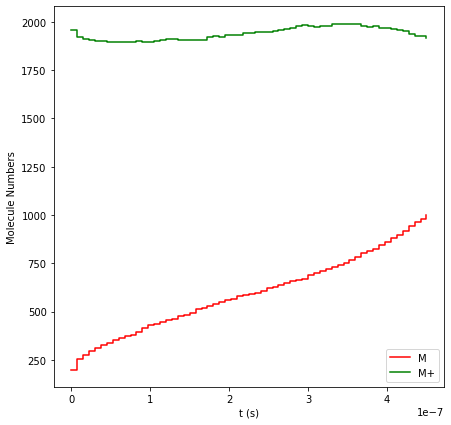

<AxesSubplot: xlabel='t (s)', ylabel='Molecule Numbers'>

In [18]:
results.plot_molecule_numbers(["M", "M+"])

To inspect the final spatial distribution of our deposited film, we can plot the last frame of the `lattice_states` trajectory (using index `[-1]`):

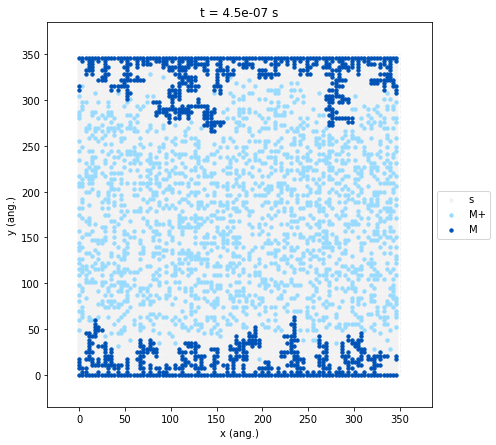

<AxesSubplot: title={'center': 't = 4.5e-07 s'}, xlabel='x (ang.)', ylabel='y (ang.)'>

In [19]:
results.plot_lattice_states(
    results.lattice_states()[-1],
    marker_size=2.5,
    markers=["o", "o"],
    colors=["#98dbff", "#0053b6"],
    lattice_color="0.95",
)

The resulting plot reveals the macroscopic morphology of the electrodeposited metal (`M`, dark blue). As expected from our kinetic parameters, the growth fronts have advanced inward from the boundaries, but the resulting deposit is highly uneven, exhibiting severe roughening and dendritic branching. This morphology is a direct consequence of our chosen reaction network. The fast electrochemical reduction rate outpaces the lateral surface diffusion (terrace diffusion and step-detachment). Furthermore, because we intentionally excluded interlayer (descending) diffusion from this minimal model, deposited atoms cannot easily relax into lower layers. This forces the system to grow outward into peaks and branches rather than forming a dense, conformal film.

As a final step, we can visualize the entire deposition process as a continuous animation. This dynamic view is often much more informative than a single final snapshot when trying to diagnose which kinetic step limits morphology evolution. The following cell uses `matplotlib.animation.ArtistAnimation` to compile our sequence of lattice states into a movie. We then use the `to_jshtml()` method to render an interactive HTML5 video player.

In [20]:
fig, ax = plt.subplots()

frames = []
results.plot_lattice_states(
    results.lattice_states(),
    show=False,
    marker_size=2.5,
    markers=["o", "o"],
    colors=["#98dbff", "#0053b6"],
    lattice_color="0.95",
    frames=frames,
)

ani = animation.ArtistAnimation(fig, frames, interval=500, blit=True)
plt.close(fig)  # prevent extra static figure display in notebook

HTML(ani.to_jshtml())

Controlling Morphology: The Low Overpotential Regime
----------------------------------------------------

You can easily alter the final morphology by shifting the kinetic balance of the simulation. If you adjust the initial parameters to a lower overpotential (`eta = 0.4`) and a longer time step (`dt = 1e-6`) to account for the slower reactions, the simulation will produce a dense, conformal film rather than dendritic branches.

<img original-file="Electrodeposition_images/Morphology-0.4V.png" src="data:image/png;base64,
...
LsfDHAAAAABJRU5ErkJggg==
" />

Achieving this film-type deposition is the ultimate goal in metal anode engineering. A flat, uniform morphology minimizes localized current density "hot spots", extends battery cycle life, and eliminates the safety hazards associated with dendrite-induced short circuits.

This shift in growth mode happens because lowering the overpotential exponentially decreases the rate of electrochemical reduction. With a much slower influx of new solid atoms, the system is no longer diffusion-limited. The deposited atoms have ample time to undergo lateral surface diffusion, allowing them to reorganize and relax into highly coordinated, tightly packed configurations before subsequent layers are formed.